<a href="https://colab.research.google.com/github/kursatkara/MAE_5020_Spring_2026/blob/master/04_02_Linear_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Linear Regression on Non-Linear Data: High Angle of Attack Aerodynamics

In aerodynamic testing, models must often handle data across a wide flight envelope. For small angles of attack ($\alpha$), the lift coefficient ($C_L$) grows linearly: $C_L = C_{L_\alpha} \cdot \alpha$. However, post-stall (high $\alpha$), the flow separates and the behavior becomes highly nonlinear.

To demonstrate the limitations of linear regression, we will attempt to fit linear error norms ($L_\infty$, $L_1$, $L_2$) to a highly curved, nonlinear dataset (modeled here simply as $\sin(\alpha)$ for wide $\alpha$ ranges up to $120^\circ$).

**Key Takeaway:** If the fundamental assumption of your model (e.g., that the data is linear) is wrong, no optimization technique or error norm will yield a good fit.

The code from the textbook [1] was modified and enhanced for this context.

[1] https://github.com/kursatkara/databook_python/blob/master/CH04/CH04_SEC01_LinearRegression.ipynb

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.optimize
from matplotlib import rcParams

# Set plotting defaults for clarity
rcParams['figure.figsize'] = [10, 6]
rcParams.update({'font.size': 12})
rcParams['axes.grid'] = True

# Function definitions for linear fit: y = m*x + c
# We optimize parameters x0 = [m, c], such that f(x) = m*x + c approximates y.
# The objective function mx + c - y = 0 is minimized according to different norms.

def fit1(x0, t):
    """L_inf norm: Maximum absolute error."""
    x, y = t
    return np.max(np.abs(x0[0]*x + x0[1] - y))

def fit2(x0, t):
    """L_1 norm: Mean absolute error."""
    x, y = t
    return np.sum(np.abs(x0[0]*x + x0[1] - y))

def fit3(x0, t):
    """L_2 norm: Least squares error."""
    x, y = t
    return np.sum((x0[0]*x + x0[1] - y)**2)

Data (alpha_deg, CL_measured):
 (array([  0,  10,  20,  30,  40,  50,  60,  70,  80,  90, 100, 110]), array([0.        , 0.17364818, 0.34202014, 0.5       , 0.64278761,
       0.76604444, 0.8660254 , 0.93969262, 0.98480775, 1.        ,
       0.98480775, 0.93969262]))
Optimization terminated successfully.
         Current function value: 0.176749
         Iterations: 78
         Function evaluations: 147
Optimization terminated successfully.
         Current function value: 1.259189
         Iterations: 53
         Function evaluations: 116
Optimization terminated successfully.
         Current function value: 0.180977
         Iterations: 64
         Function evaluations: 118

--- Regression Results ---
Line fits for L_inf (Maximum Error) : slope=0.0085, intercept=0.1767
Line fits for L_1 (Mean Abs Error)  : slope=0.0095, intercept=0.1699
Line fits for L_2 (Least Sq Error)  : slope=0.0090, intercept=0.1849


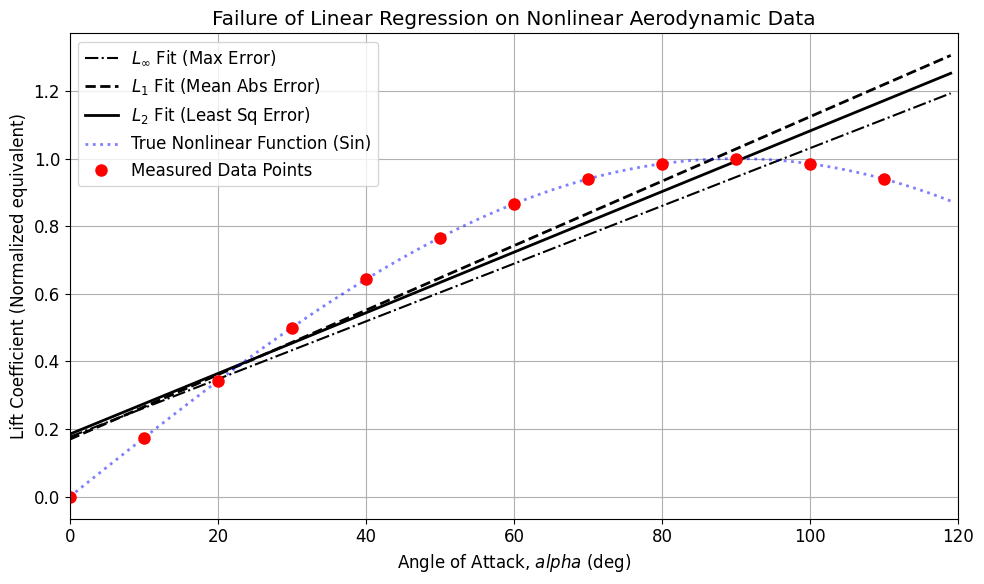

In [2]:
# Wide Envelope Angle of Attack Data (Degrees)
# We test from 0 to 120 degrees in steps of 10.
alpha_deg = np.arange(0, 120, 10)

# Highly nonlinear response loosely modeled as sine
CL_measured = np.sin(np.radians(alpha_deg))

t = (alpha_deg, CL_measured)
print("Data (alpha_deg, CL_measured):\n", t)

# Initial guess for linear model [slope, intercept]
x0 = np.array([1.0, 1.0])

# Minimize the objective functions
p1 = scipy.optimize.fmin(fit1, x0, args=(t,))
p2 = scipy.optimize.fmin(fit2, x0, args=(t,))
p3 = scipy.optimize.fmin(fit3, x0, args=(t,))

print("\n--- Regression Results ---")
print(f"Line fits for L_inf (Maximum Error) : slope={p1[0]:.4f}, intercept={p1[1]:.4f}")
print(f"Line fits for L_1 (Mean Abs Error)  : slope={p2[0]:.4f}, intercept={p2[1]:.4f}")
print(f"Line fits for L_2 (Least Sq Error)  : slope={p3[0]:.4f}, intercept={p3[1]:.4f}")

# Generate dense x-coordinates to show the smooth true model
alpha_fine = np.arange(0, 120, 1)

# Linear predictions
CL_fit_Linf = np.polyval(p1, alpha_fine)
CL_fit_L1   = np.polyval(p2, alpha_fine)
CL_fit_L2   = np.polyval(p3, alpha_fine)

# Underlying true nonlinear response for plotting reference
CL_true = np.sin(np.radians(alpha_fine))

# Plotting the results
plt.figure()

# Plot the fits
plt.plot(alpha_fine, CL_fit_Linf, '-.', color='k', label=r'$L_{\infty}$ Fit (Max Error)')
plt.plot(alpha_fine, CL_fit_L1, '--', color='k', linewidth=2, label=r'$L_{1}$ Fit (Mean Abs Error)')
plt.plot(alpha_fine, CL_fit_L2, color='k', linewidth=2, label=r'$L_{2}$ Fit (Least Sq Error)')

# Plot true curve and measured data
plt.plot(alpha_fine, CL_true, ':', color='b', alpha=0.5, linewidth=2, label=r'True Nonlinear Function (Sin)')
plt.plot(alpha_deg, CL_measured, 'o', color='r', markersize=8, label='Measured Data Points')

plt.xlim(0, 120)
plt.xlabel(r'Angle of Attack, $alpha$ (deg)')
plt.ylabel(r'Lift Coefficient (Normalized equivalent)')
plt.title('Failure of Linear Regression on Nonlinear Aerodynamic Data')
plt.legend()
plt.tight_layout()
plt.show()

### Challenge Problem: Polynomial Feature Expansion
As we saw, linear regression fails on nonlinear (post-stall) aerodynamic data. However, we can still use underlying linear solver technology if we expand our feature space. Your challenge is to use `PolynomialFeatures` from Scikit-Learn to transform the single `alpha` input into polynomial terms [alpha, alpha^2, alpha^3, ...], and fit a high-degree polynomial to the sine-wave data using a standard LinearRegression model.

In [ ]:
# YOUR CODE HERE
# 1. Reshape alpha_deg for sklearn
# 2. Use PolynomialFeatures(degree=5) to transform the input
# 3. Fit a LinearRegression model to the transformed features
# 4. Plot the predicted polynomial curve against the true sine curve
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
# ...

<details>
<summary><b>Click to Reveal Solution</b></summary>

```python
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

# 1. Reshape for sklearn
X = alpha_deg.reshape(-1, 1)
y = CL_measured

# 2. Polynomial transformation
poly = PolynomialFeatures(degree=5)
X_poly = poly.fit_transform(X)

# 3. Fit model
model = LinearRegression()
model.fit(X_poly, y)

# 4. Predict and plot
X_fine = alpha_fine.reshape(-1, 1)
X_fine_poly = poly.transform(X_fine)
y_pred = model.predict(X_fine_poly)

plt.figure(figsize=(10,6))
plt.plot(alpha_fine, CL_true, 'b:', linewidth=3, label='True Sine Curve')
plt.scatter(alpha_deg, y, color='red', s=50, label='Measured Data')
plt.plot(alpha_fine, y_pred, 'g-', linewidth=2, label='Degree-5 Polynomial Fit')
plt.legend()
plt.xlabel('Angle of Attack (deg)')
plt.ylabel('Lift Coefficient')
plt.title('Nonlinear Fitting using Polynomial Feature Expansion')
plt.grid(True)
plt.show()
```
</details>